In [ ]:
from vkt.core import Crossing, StrandRef,connect, disconnect
from vkt.core import parse_gauss_code, VirtualLink, VirtualLinkDiagram
from vkt.core.arc_routing_strandref import route_arc_from_strandref
from vkt.core import Crossing, StrandRef,connect, disconnect
from vkt.core.seifert_nesting import seifert_nesting

In [4]:
gc = 'O1-U2-O3+U1-O4-U5-O6-U3+O2-U4-O5-U6-'
crossings = parse_gauss_code(gc)
link = VirtualLink(crossings)
link_diagram= VirtualLinkDiagram(link)

NameError: name '_event_sort_key' is not defined

In [7]:
link_diagram.arc_routes

{StrandRef(crossing=0, strand=0): [Segment[H]((0, 1) → (3, 1)),
  Segment[V]((3, 1) → (3, 4))],
 StrandRef(crossing=0, strand=1): [Segment[H]((1, 0) → (12, 0)),
  Segment[V]((12, 0) → (12, 11))],
 StrandRef(crossing=1, strand=0): [Segment[H]((4, 5) → (11, 5)),
  Segment[V]((11, 5) → (11, 12))],
 StrandRef(crossing=1, strand=1): [Segment[H]((5, 4) → (7, 4)),
  Segment[V]((7, 4) → (7, 8))],
 StrandRef(crossing=2, strand=0): [Segment[H]((8, 9) → (2, 9)),
  Segment[V]((2, 9) → (2, 3)),
  Segment[H]((2, 3) → (4, 3))],
 StrandRef(crossing=2, strand=1): [Segment[V]((9, 8) → (9, 10)),
  Segment[H]((9, 10) → (-1, 10)),
  Segment[V]((-1, 10) → (-1, 0))],
 StrandRef(crossing=3, strand=0): [Segment[H]((12, 13) → (15, 13)),
  Segment[V]((15, 13) → (15, 16))],
 StrandRef(crossing=3, strand=1): [Segment[H]((13, 12) → (16, 12)),
  Segment[V]((16, 12) → (16, 15))],
 StrandRef(crossing=4, strand=0): [Segment[H]((16, 17) → (19, 17)),
  Segment[V]((19, 17) → (19, 20))],
 StrandRef(crossing=4, strand=1): [

ValueError: End crossing (id=6) must be classical, got virtual

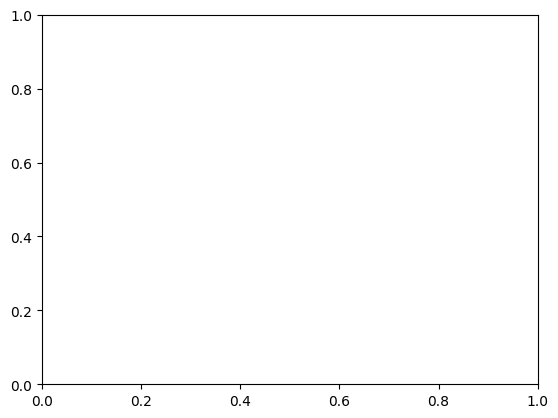

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

all_vals = []

# Plot arcs
for crossing in link.crossings:
    for i in range(2):
        result = route_arc_from_strandref(crossing.ref(i))
        if result is None:
            continue
        xs, ys = result
        all_vals.extend(xs)
        all_vals.extend(ys)
        ax.plot(xs, ys, color='steelblue')

# Plot crossings
for n, crossing in enumerate(link.crossings):
    cx, cy = 4 * n, 4 * n
    if crossing.sign == 1:  # positive: x-axis over, y-axis broken
        ax.plot([cx - 1, cx + 1], [cy, cy], color='black')
        ax.plot([cx, cx], [cy - 1, cy - 0.2], color='black')
        ax.plot([cx, cx], [cy + 0.2, cy + 1], color='black')
    else:  # negative: y-axis over, x-axis broken
        ax.plot([cx, cx], [cy - 1, cy + 1], color='black')
        ax.plot([cx - 1, cx - 0.2], [cy, cy], color='black')
        ax.plot([cx + 0.2, cx + 1], [cy, cy], color='black')

lim = [min(all_vals), max(all_vals)]
ax.plot(lim, [v + 1 for v in lim], color='red', linestyle='--', alpha = .3)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

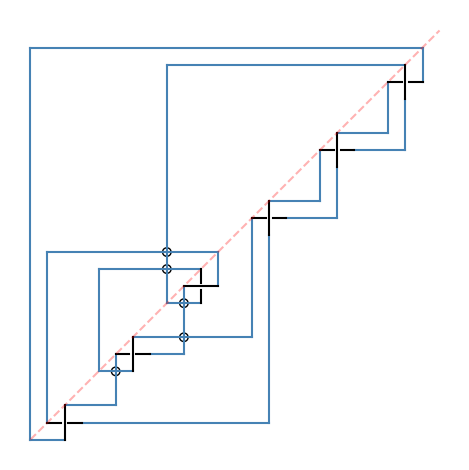

<Axes: >

In [9]:
link_diagram.plot()

In [11]:
link_diagram.arc_routes.keys()

dict_keys([StrandRef(crossing=0, strand=0), StrandRef(crossing=0, strand=1), StrandRef(crossing=1, strand=0), StrandRef(crossing=1, strand=1), StrandRef(crossing=2, strand=0), StrandRef(crossing=2, strand=1), StrandRef(crossing=3, strand=0), StrandRef(crossing=3, strand=1), StrandRef(crossing=4, strand=0), StrandRef(crossing=4, strand=1), StrandRef(crossing=5, strand=0), StrandRef(crossing=5, strand=1)])

In [2]:
gc = 'O1+O2-U1+O3+O4-U5-U2-U3+O6+O5-U4-U6+'
crossings = parse_gauss_code(gc)
link = VirtualLink(crossings)
link_diagram = VirtualLinkDiagram(link)
#link_diagram.compute_arc_routes()
link_diagram.plot()
print(len(link_diagram.crossings))
print(len(link_diagram.components()))
print(len(link_diagram.seifert_components()))

NameError: name '_event_sort_key' is not defined

In [27]:
sc = link_diagram.seifert_components()
sc[4]

[StrandRef(crossing=4, strand=0),
 StrandRef(crossing=13, strand=1),
 StrandRef(crossing=13, strand=0),
 StrandRef(crossing=12, strand=1),
 StrandRef(crossing=12, strand=0),
 StrandRef(crossing=4, strand=1)]

In [15]:
link_diagram.update_arc_routes()

AttributeError: 'VirtualLinkDiagram' object has no attribute '_split_segments_at'

In [28]:
seifert_nesting(link_diagram)

([(-2, 4, 2), (-1, 20, 0), (3, 17, 3), (11, 16, 4), (14, 21, 1)],
 [-1, 0, 1, 2, 3])

In [22]:
for i, circle in enumerate(link_diagram.seifert_components()):
    print(f"Component {i}:")
    for ref in circle:
        if ref in link_diagram.arc_routes:
            for seg in link_diagram.arc_routes[ref]:
                print(f"  {seg.start} -> {seg.end}")

Component 0:
  (0, 1) -> (7, 1)
  (7, 1) -> (7, 8)
  (4, 5) -> (-2, 5)
  (-2, 5) -> (-2, -1)
  (-2, -1) -> (0, -1)
  (5, 4) -> (8, 4)
  (8, 4) -> (8, 7)
  (9, 8) -> (12, 8)
  (12, 8) -> (12, 11)
  (8, 9) -> (19, 9)
  (19, 9) -> (19, 20)
  (12, 13) -> (15, 13)
  (15, 13) -> (15, 16)
  (13, 12) -> (20, 12)
  (20, 12) -> (20, 19)
  (21, 20) -> (21, 22)
  (21, 22) -> (14, 22)
  (14, 22) -> (14, 15)
  (14, 15) -> (16, 15)
  (20, 21) -> (-1, 21)
  (-1, 21) -> (-1, 0)
  (1, 0) -> (4, 0)
  (4, 0) -> (4, 3)
Component 1:
  (1, 0) -> (4, 0)
  (4, 0) -> (4, 3)
  (8, 9) -> (19, 9)
  (19, 9) -> (19, 20)
  (9, 8) -> (12, 8)
  (12, 8) -> (12, 11)
  (20, 21) -> (-1, 21)
  (-1, 21) -> (-1, 0)
  (21, 20) -> (21, 22)
  (21, 22) -> (14, 22)
  (14, 22) -> (14, 15)
  (14, 15) -> (16, 15)
  (0, 1) -> (7, 1)
  (7, 1) -> (7, 8)
Component 2:
  (4, 5) -> (-2, 5)
  (-2, 5) -> (-2, -1)
  (-2, -1) -> (0, -1)
  (5, 4) -> (8, 4)
  (8, 4) -> (8, 7)
Component 3:
  (12, 13) -> (15, 13)
  (15, 13) -> (15, 16)
  (16, 17) -

In [5]:
link_diagram.seifert_components()

[[StrandRef(crossing=0, strand=0),
  StrandRef(crossing=4, strand=1),
  StrandRef(crossing=4, strand=0),
  StrandRef(crossing=1, strand=1),
  StrandRef(crossing=1, strand=0),
  StrandRef(crossing=0, strand=1)],
 [StrandRef(crossing=0, strand=1),
  StrandRef(crossing=4, strand=0),
  StrandRef(crossing=4, strand=1),
  StrandRef(crossing=1, strand=0),
  StrandRef(crossing=1, strand=1),
  StrandRef(crossing=2, strand=0),
  StrandRef(crossing=2, strand=1),
  StrandRef(crossing=5, strand=0),
  StrandRef(crossing=5, strand=1),
  StrandRef(crossing=3, strand=0),
  StrandRef(crossing=3, strand=1),
  StrandRef(crossing=0, strand=0)],
 [StrandRef(crossing=2, strand=0),
  StrandRef(crossing=5, strand=1),
  StrandRef(crossing=5, strand=0),
  StrandRef(crossing=3, strand=1),
  StrandRef(crossing=3, strand=0),
  StrandRef(crossing=2, strand=1)]]